In [35]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import sys
import cv2 
from skimage import io, feature, exposure
sys.path.append(r"C:\Users\sjefs\Desktop\Uni\Speciale\Kode\library")
import CV_functions as CV_func
import CV_classes as CV_class
from PIL import Image
from PIL.TiffTags import TAGS
import matplotlib.pyplot as plt
import scipy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Idea
For ML we need some features. Currently we just have the pixel intensity as a feature. We need to add something that gives the pixel an idea of its surroundings, such as:
- Local neighborhood statistics (e.g., mean, variance)
- Gradient magnitude


Nice things to check out
- Cellprofiler
- Youtube series on CV : https://www.youtube.com/watch?v=22mpExWh1LY&list=PL2zRqk16wsdop2EatuowXBX5C-r2FdyNt&index=4
- Deep learning models : Mask R-CNN, CellViT, or CellSAM.


# Pre Processing

In [106]:
# Load a data file
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t20_maxZ.tif"
test_image = CV_class.Picture(test_path)
test_image.blur()
test_array = test_image.array

# Shorten it for testing
cut = 512
test_array = test_array[:cut, :cut]

## Local statistics

We add statistics, such that we end with a feature [intensity, local mean, local variance, x, y]

Other features could include gradient information, texture descriptors, or higher-order local statistics.
- Region mean/variance. (a larger area than the local)
- Gradient magnitude.
- Texture descriptors (e.g., Local Binary Patterns).
- Higher-order local statistics (e.g., skewness, kurtosis).

In [107]:
# We want features loke [intensity, local_mean, Local_variance, x, y]

N_features = 7
features = np.zeros(
    (test_array.shape[0], test_array.shape[1], N_features),
    dtype=np.float64
)

neighborhood_size = 5
total_pixels = test_array.shape[0] * test_array.shape[1]
next_progress = 10

for i in range(test_array.shape[0]):
    for j in range(test_array.shape[1]):
        neighborhood = test_array[
            max(0, i - neighborhood_size):min(test_array.shape[0], i + neighborhood_size + 1),
            max(0, j - neighborhood_size):min(test_array.shape[1], j + neighborhood_size + 1)
        ]

        local_mean = np.mean(neighborhood)
        local_variance = np.var(neighborhood)
        local_median = np.median(neighborhood)
        local_minmax = np.ptp(neighborhood)


        features[i, j] = np.array([
            test_array[i, j],
            local_mean,
            local_variance,
            local_median,
            local_minmax,
            i,
            j
        ])

        completed = i * test_array.shape[1] + j + 1
        progress = completed / total_pixels * 100

        if progress >= next_progress:
            print(f"Progress: {next_progress}%")
            next_progress += 10


Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%
Progress: 100%


## Normalization

In [95]:
# Perform normalization down to the range [0,1]. I want to be able to scale up after clustering
features = (features - np.min(features, axis=(0, 1))) / (np.max(features, axis=(0, 1)) - np.min(features, axis=(0, 1)))
scale_factor = np.max(features, axis=(0, 1)) - np.min(features, axis=(0, 1))

## Gradients

In [ ]:
# Lets also find the gradients
grad_y = cv2.Sobel(test_array, cv2.CV_64F, 0, 1)
grad_x = cv2.Sobel(test_array, cv2.CV_64F, 1, 0)
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
grad_direction = np.arctan2(grad_y, grad_x)


# Different algorithms

Ward was bad

## Kmeans

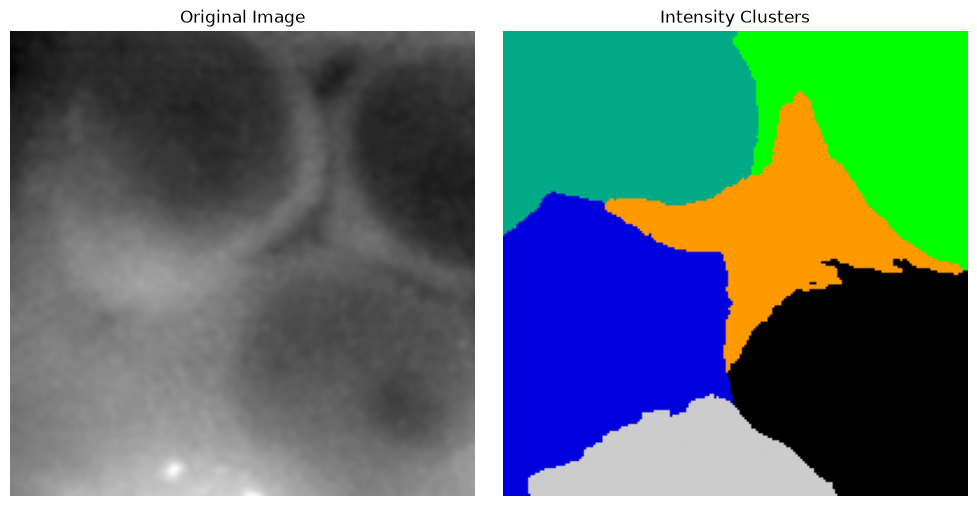

In [102]:
from sklearn.cluster import KMeans

# Work with the features array
pixels = features.reshape(-1, N_features).astype(np.float32)

kmeans = KMeans(
    n_clusters=6,
    random_state=0,
    n_init='auto'
)

labels = kmeans.fit_predict(pixels)
label_im = labels.reshape(test_array.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_array, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Intensity Clusters")
plt.imshow(label_im, cmap="nipy_spectral", vmin=0, vmax=5)
plt.axis("off")


plt.tight_layout()
plt.show()

## Kmeans++

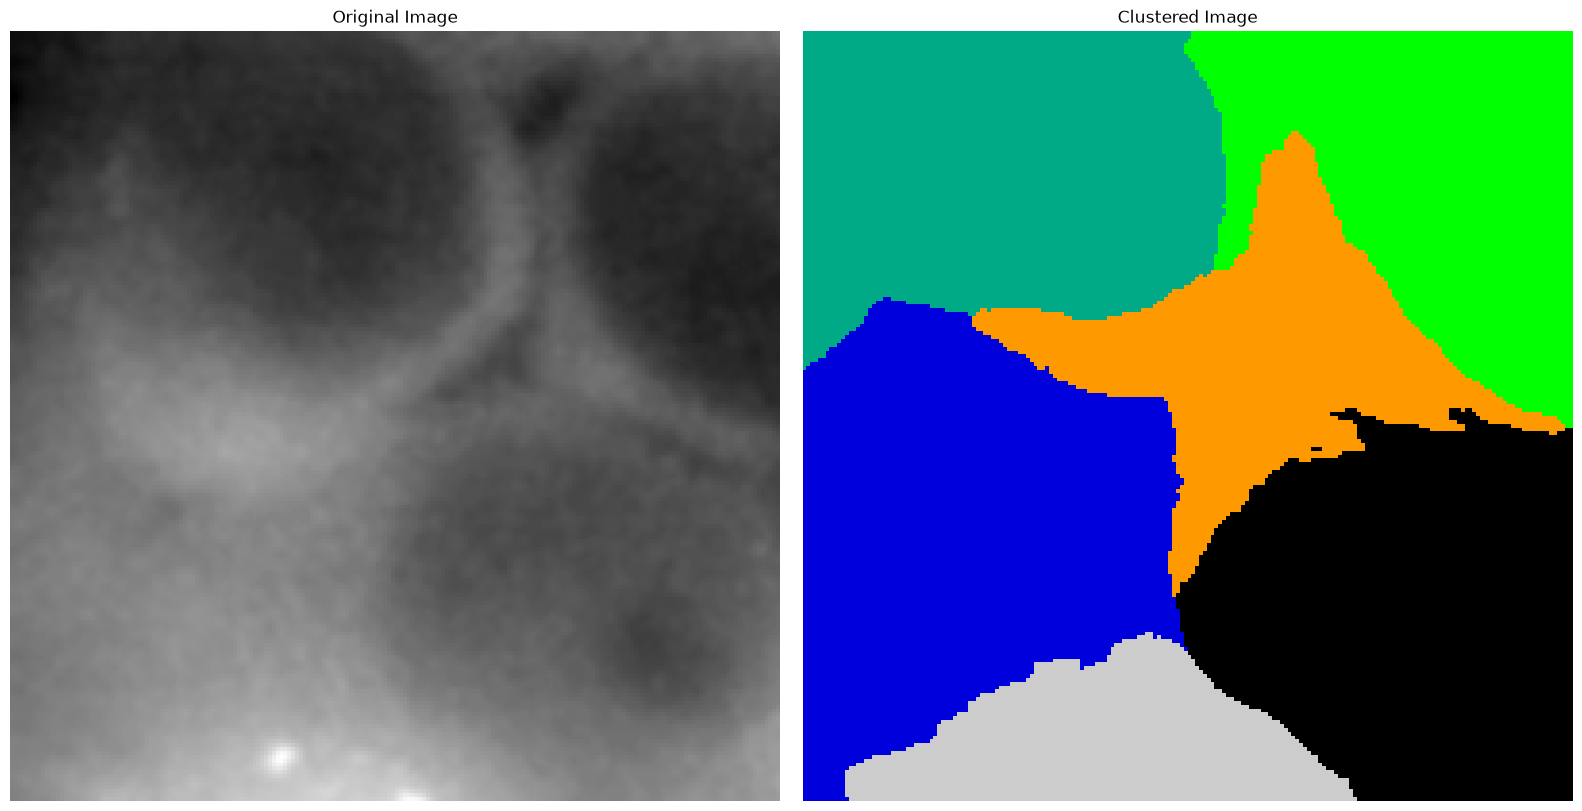

In [104]:
from sklearn.cluster import kmeans_plusplus

# Work with the features array
n_clusters = 6
pixels = features.reshape(-1, N_features).astype(np.float32)
centers_init, indices = kmeans_plusplus(pixels, n_clusters=n_clusters, random_state=0)

# Now run k-means with the initialized centers
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=n_clusters, init=centers_init, n_init=1, random_state=0)
kmeans.fit(pixels)

# Display the clusters next to the original image
labels = kmeans.labels_.reshape(test_array.shape)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(test_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(labels, cmap="nipy_spectral", vmin=0, vmax=n_clusters - 1)
plt.title("Clustered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## Meanshift

In [105]:
# Apply Mean Shift clustering to the feature vectors
from sklearn.cluster import MeanShift

# Use all five features: intensity, local mean, local variance, x, and y
pixels = features.reshape(-1, N_features).astype(np.float32)

mean_shift = MeanShift(
    bandwidth=0.2,   # Adjust this value to control cluster size
)

clustering = mean_shift.fit_predict(pixels)
mean_shift_labels = clustering.reshape(test_array.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_array, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Mean Shift Segmentation ({len(mean_shift.cluster_centers_)} clusters)")
plt.imshow(mean_shift_labels, cmap="nipy_spectral")
plt.axis("off")

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

## Ward

In [24]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances_argmin_min

# DBSCAN parameters; tune eps depending on the desired cluster density
eps = 0.02
min_samples = 20

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric="euclidean",
    n_jobs=-1
)

sample_labels = dbscan.fit_predict(sample_features)

# DBSCAN labels noise points as -1
dbscan_core_indices = dbscan.core_sample_indices_

if len(dbscan_core_indices) == 0:
    raise ValueError(
        "DBSCAN found no core samples. Increase eps or decrease min_samples."
    )

core_features = sample_features[dbscan_core_indices]
core_labels = sample_labels[dbscan_core_indices]

# Assign every pixel to its nearest DBSCAN core sample
pixels = features.reshape(-1, N_features).astype(np.float32)

nearest_core_indices, nearest_distances = pairwise_distances_argmin_min(
    pixels,
    core_features
)

dbscan_labels = core_labels[nearest_core_indices]

# Pixels farther than eps from every core sample are treated as noise
dbscan_labels[nearest_distances > eps] = -1

dbscan_label_im = dbscan_labels.reshape(test_array.shape)

# Plot the result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_array, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
n_dbscan_clusters = len(set(sample_labels)) - (1 if -1 in sample_labels else 0)
plt.title(f"DBSCAN ({n_dbscan_clusters} clusters, noise included)")
plt.imshow(
    dbscan_label_im,
    cmap="nipy_spectral",
    vmin=-1,
    vmax=max(0, n_dbscan_clusters - 1)
)
plt.axis("off")

plt.tight_layout()
plt.show()

ValueError: DBSCAN found no core samples. Increase eps or decrease min_samples.